<a href="https://colab.research.google.com/github/abhisakh/XGBOOST_Machine_Leraning_Predictor_Titanic/blob/main/Titanic_XGBoost_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 1 (Load the raw dataset [Titanic](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv))

In [25]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## STEP 1.a (Analyze the shape and datastructure)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## STEP 1.c Find the missing Data for feature column

In [27]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_summary


,Missing Count,Missing Percentage (%)
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


### The Problem:
A few passengers had missing data (blanks) for the port where they boarded the ship.

### The Fix: (Filling Blank Spaces (.fillna and .mode()))
The .mode()[0] finds the most common boarding port in the entire dataset (which is 'S' for Southampton). The .fillna() function automatically replaces those blank spaces with that most frequent port so we do not have to throw away those passenger rows.

### The Problem:
The Embarked column contains text letters ('S', 'C', 'Q') representing different cities, but mathematical tools like correlation formulas and XGBoost can only read numbers.

### The Fix: (Converting Text to Numbers (.astype('category').cat.codes))
This converts the text into a category format and assigns a unique number code to each city (for example, 'C' becomes 0, 'Q' becomes 1, and 'S' becomes 2). Now, the column is fully readable for the pre-correlation analysis.

## STEP 2: Clean the Data for correlation analysis
In this cell, we convert text columns to numbers and handle missing values so that math formulas can read the entire dataset

In [30]:
# df.head()

In [29]:
# Convert all text categories into numbers
df_clean = df.copy()
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Embarked'] = df_clean['Embarked'].astype('category').cat.codes

# Fill missing ages with the median age
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Drop completely unique text IDs that have no mathematical trend
df_clean = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df_clean.head()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int8   
dtypes: float64(2), int64(5), int8(1)
memory usage: 49.7 KB


## STEP 2a: Precorrelation analysis before dropping any further feature
In this cell, we calculate and visualize how every single feature relates to survival before making any final selection choices.

Full Correlation with Survived:
Survived    1.000000
Sex         0.543351
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Embarked   -0.167675
Pclass     -0.338481
Name: Survived, dtype: float64


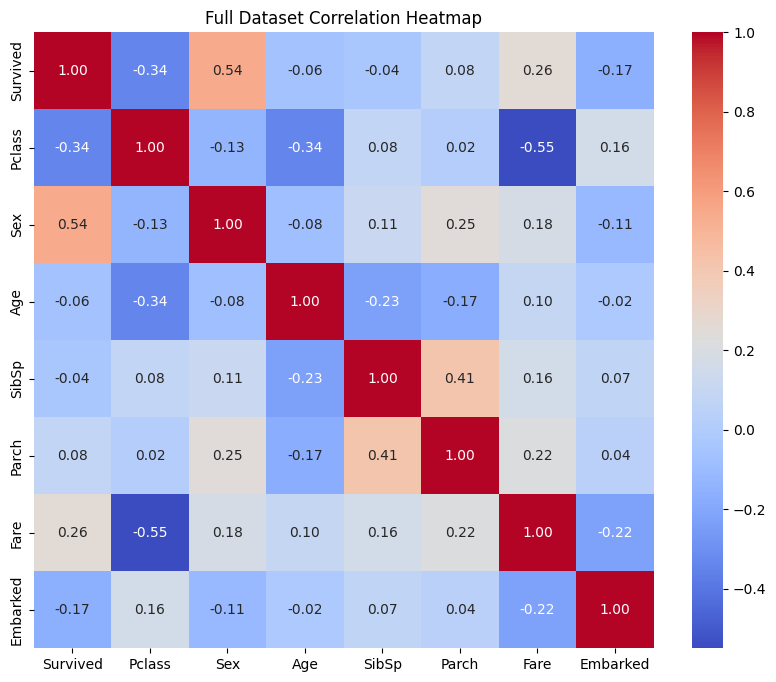

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation for all cleaned features
all_correlations = df_clean.corr()

# Print the mathematical relationship numbers
print("Full Correlation with Survived:")
print(all_correlations['Survived'].sort_values(ascending=False))

# Plot the complete heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(all_correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Full Dataset Correlation Heatmap")
plt.show()

## STEP 2b: Precorrelation anaysis report
#### 1. The Strongest Predictors
**Sex (0.54):** This is the strongest positive number. Because we coded females as 1 and males as 0, this high positive correlation confirms the "women and children first" rescue policy—being female is strongly linked to survival.

**Pclass (-0.34):** This is the strongest negative number. The negative sign means as the class number goes up (from 1st class down to 3rd class), the chance of survival goes down. First-class passengers had a major advantage.

#### 2. The Supporting Features
**Fare (0.26):** A positive link, which matches the Pclass finding. Passengers who paid higher fares had a better chance of surviving.

**Embarked (-0.17):** This negative correlation shows that the port where people boarded had a slight statistical relationship with survival, likely because certain ports had a higher concentration of 3rd class passengers.

#### 3. The Weakest Linear Links
**Age (-0.06), SibSp (-0.04), and Parch (0.08):** On their own, these numbers are very close to 0, meaning they do not have a straight, linear relationship with survival.

#### 💡 Why XGBoost is perfect here:
Standard correlation only finds straight-line relationships. It misses complex rules, like "Age matters a lot, but only if the passenger is a young child." XGBoost will look at these weak columns and find those hidden, non-linear patterns automatically!

## STEP 3: Split, Train, and Score the Model
In this cell, we separate our target, split the data to prevent cheating, and train the XGBoost model on our full set of features.

In [33]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Separate features (X) and target (y)
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train the XGBoost model
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

# Calculate and print the final accuracy
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy on Full Features: {accuracy * 100:.2f}%")

Model Accuracy on Full Features: 81.01%


## The baseline score 81.01%.
Because we did not specify settings like the number of trees or depth, Python automatically used XGBoost's built-in default hyperparameters.

By default, the XGBClassifier automatically applied these standard settings behind the scenes:

n_estimators = 100 (It built exactly 100 decision trees)

max_depth = 6 (Each tree was allowed to grow up to 6 layers deep)

learning_rate = 0.3 (The step size or speed at which the model learns)

Our next official step in the project will be Hyperparameter Tuning, where we adjust these settings away from the defaults to see if we can beat that 81% baseline score!

Establishing a baseline with default hyperparameters is a foundational best practice in machine learning because it gives us an objective benchmark to measure future progress against. Without this starting score, it is impossible to know if manually tweaking complex settings like tree depth or learning rate is actually improving your model or making it worse. It separates the initial data preparation phase from the optimization phase, ensuring that any boost in accuracy you achieve next through hyperparameter tuning is a proven, measurable success rather than random guesswork.